c:\Users\User_Valerio\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:40:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


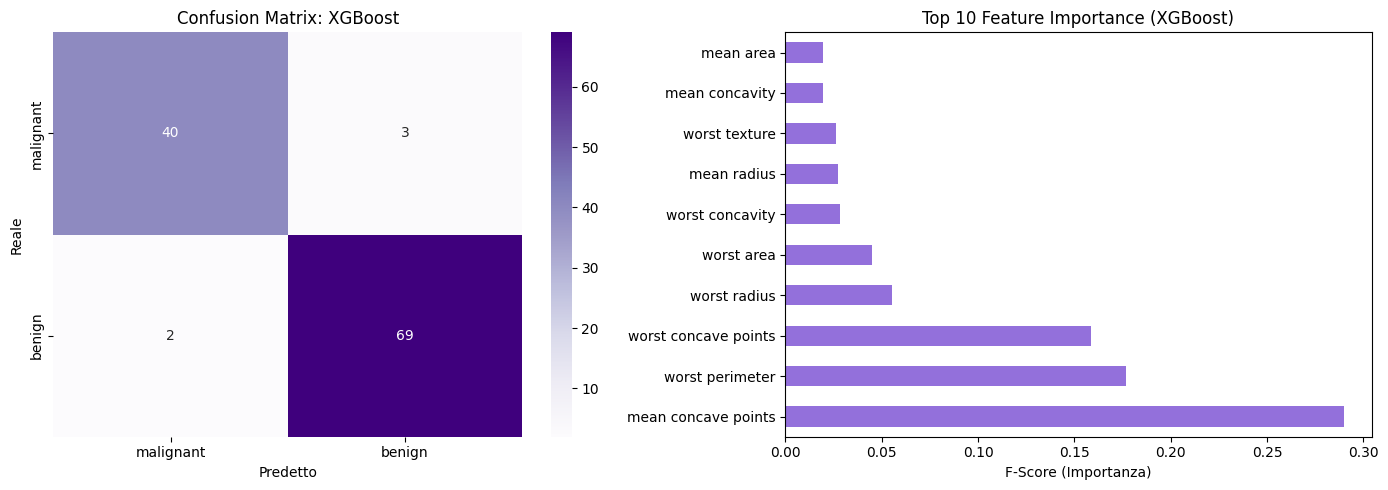

Accuratezza XGBoost: 95.61%

Report Tecnico:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# È necessario installare xgboost: !pip install xgboost
from xgboost import XGBClassifier

# 1. Preparazione dei dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurazione del modello XGBoost
# I parametri chiave:
# n_estimators: numero di alberi sequenziali
# learning_rate (eta): quanto pesano le correzioni di ogni nuovo albero (previene overfitting)
# max_depth: profondità di ogni albero
# gamma: parametro di regolarizzazione (minima riduzione della perdita per fare uno split)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss', # Evita i warning e specifica la funzione di costo
    random_state=42
)

# 3. Addestramento
xgb_model.fit(X_train, y_train)

# 4. Predizione
y_pred = xgb_model.predict(X_test)

# --- VISUALIZZAZIONE RISULTATI ---
plt.figure(figsize=(14, 5))

# Grafico 1: Matrice di Confusione
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# Grafico 2: Feature Importance di XGBoost
plt.subplot(1, 2, 2)
# XGBoost ha un suo metodo per calcolare l'importanza delle feature
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('F-Score (Importanza)')

plt.tight_layout()
plt.show()

# Metriche finali
print(f"Accuratezza XGBoost: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

In [3]:
#precision recall f1-score support
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

#albero decisionale sul df di titanic che stavo usando prima, con target "survived" e tutte le altre colonne come feature
X = df_zscore.drop(columns=['survived']).values
y = df_zscore['survived'].values

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Addestramento del modello XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predizione
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

NameError: name 'df_zscore' is not defined